In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_AR_from_Q


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/dic_vert_doppio_AMEDA.pkl')


Things to compare
1. max r
2. max tangential velocity
3. vorticity
4. area

In [7]:
df_phys_geom = df_ameda[['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'xc', 'yc', 'w',
       'ke', 'velmax', 'rmax', 'Age', 'Date', 'fname', 'shapes1', 'area', 'deta']]

df_phys_geom = df_phys_geom.rename(columns={
                    'lon': 'plon',
                    'lat': 'plat',
                    'xc': 'pxc',
                    'yc': 'pyc',
                    'w': 'pw',
                })

cols = ['xc', 'yc',
    'w', 'Omega', 'Q',
    'Rc', 'psi0', 'R'
]

out = []

for row in df_phys_geom.itertuples(index=False):

    # try:
    df = dic_vert[f'Eddy{row.Eddy}'][f'Day{row.Day}']
    if len(df):
        data_top = df.iloc[0][cols]
    else:
        data_top = pd.Series(np.nan, index=cols)

    out.append(data_top)

df_top = pd.DataFrame(out).reset_index(drop=True)

df_phys_geom = pd.concat(
    [df_phys_geom.reset_index(drop=True), df_top],
    axis=1
)

df_phys_geom = df_phys_geom.rename(columns={
                    'xc': 'gxc',
                    'yc': 'gyc',
                    'w': 'gw',
                })


In [8]:
df_phys_geom


,Eddy,Day,Cyc,plon,plat,pxc,pyc,pw,ke,velmax,...,area,deta,gxc,gyc,gw,Omega,Q,Rc,psi0,R
0,1,1462,AE,159.538447,-33.372496,895.838095,919.548973,0.000010,292.285615,0.544839,...,46653.514371,-0.000011,896.935404,914.018437,0.000027,0.000016,"[[1.1484970435920865, -0.16686898267851438], [...",76.216389,-4.709353e+01,50.205273
1,1,1463,AE,159.686966,-33.160751,903.002279,946.853133,0.000019,11.362536,0.345677,...,4313.383226,-0.000164,902.383771,945.300803,0.000027,0.000013,"[[1.1014165403553098, 0.08390953388558413], [0...",84.056157,-4.612005e+01,56.641660
2,1,1464,AE,159.649836,-33.118402,898.424872,950.150915,0.000019,12.635252,0.358493,...,4336.799061,-0.000070,899.147518,951.755290,0.000028,0.000014,"[[1.1474072104379092, 0.09543483784981353], [0...",70.983917,-3.550560e+01,46.977663
3,1,1465,AE,159.686966,-33.118402,901.765461,951.353349,0.000019,29.826388,0.435328,...,6480.379311,-0.000047,899.529964,953.702712,0.000032,0.000015,"[[1.0369072488316746, 0.24215822157703532], [0...",70.511257,-3.841341e+01,48.730042
4,1,1466,AE,159.575577,-32.949006,886.770848,965.738198,0.000020,28.475320,0.442656,...,6101.676103,-0.000401,884.763262,960.347517,0.000035,0.000016,"[[1.022111462750352, 0.14391176963720498], [0....",65.650567,-3.539335e+01,43.505985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,327.112431,1244.142958,-0.000014,0.302780,0.127185,...,1147.953129,0.000186,325.073024,1240.337375,-0.000016,-0.000009,"[[0.7772149834805244, 0.4056803792731006], [0....",115.522788,6.287183e+01,62.433731
104566,3519,10647,CE,154.860106,-29.052897,331.141370,1220.843200,-0.000011,14.401765,0.221221,...,8038.013328,0.000109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104567,3519,10648,CE,154.897235,-29.222293,340.502393,1204.416117,-0.000011,16.134916,0.250150,...,9866.414298,0.000095,296.774362,1242.855587,-0.000024,-0.000003,"[[2.379027060784385, 2.3814168849882056], [2.3...",24951.145880,1.050213e+06,33.659059
104568,3519,10649,CE,154.377420,-28.417662,264.105244,1270.945276,-0.000010,3.093473,0.189983,...,5581.424065,0.000003,277.032905,1262.259287,-0.000015,-0.000006,"[[1.0691646288134213, 0.4616523150827176], [0....",60.067356,1.071680e+01,23.061186


In [11]:
def is_valid_Q(Q):
    return isinstance(Q, np.ndarray) and Q.shape == (2, 2) and np.isfinite(Q).all()

ARs = np.full(len(df_phys_geom), np.nan)

valid = df_phys_geom['Q'].apply(is_valid_Q)

if valid.any():
    Q_stack = np.stack(df_phys_geom.loc[valid, 'Q'].values)
    ARs[valid.values] = compute_AR_from_Q(Q_stack)

df_phys_geom['AR'] = ARs


In [12]:
# Check AR
# if poor only keep Eddy, Day, Cyc, xc, yc, R
# replace the rest NaN

df_phys_geom_QC = df_phys_geom.copy()

AR_mask = df_phys_geom_QC['AR'] > 5
cols_to_nan = [
    'gw', 'Omega',
    'Q', 'Rc', 'psi0', 'AR'
]
df_phys_geom_QC.loc[AR_mask, cols_to_nan] = np.nan

# Check Omega, Rc, psi0 i.e. poor outer-core fits
poor_outer_fits = (
    (df_phys_geom_QC['Rc'] > 300)
    | (df_phys_geom_QC['Rc'] > 1.75*df_phys_geom_QC['R'])
    | (df_phys_geom_QC['Omega'].abs() > 5e-5)
    | (df_phys_geom_QC['psi0'].abs() > 300)
)

# remove poor outer-core parameters
df_phys_geom_QC.loc[poor_outer_fits, ['Rc', 'psi0']] = np.nan

df_phys_geom_QC


,Eddy,Day,Cyc,plon,plat,pxc,pyc,pw,ke,velmax,...,deta,gxc,gyc,gw,Omega,Q,Rc,psi0,R,AR
0,1,1462,AE,159.538447,-33.372496,895.838095,919.548973,0.000010,292.285615,0.544839,...,-0.000011,896.935404,914.018437,0.000027,0.000016,"[[1.1484970435920865, -0.16686898267851438], [...",76.216389,-47.093534,50.205273,1.231286
1,1,1463,AE,159.686966,-33.160751,903.002279,946.853133,0.000019,11.362536,0.345677,...,-0.000164,902.383771,945.300803,0.000027,0.000013,"[[1.1014165403553098, 0.08390953388558413], [0...",84.056157,-46.120052,56.641660,1.133534
2,1,1464,AE,159.649836,-33.118402,898.424872,950.150915,0.000019,12.635252,0.358493,...,-0.000070,899.147518,951.755290,0.000028,0.000014,"[[1.1474072104379092, 0.09543483784981353], [0...",70.983917,-35.505599,46.977663,1.177924
3,1,1465,AE,159.686966,-33.118402,901.765461,951.353349,0.000019,29.826388,0.435328,...,-0.000047,899.529964,953.702712,0.000032,0.000015,"[[1.0369072488316746, 0.24215822157703532], [0...",70.511257,-38.413409,48.730042,1.271223
4,1,1466,AE,159.575577,-32.949006,886.770848,965.738198,0.000020,28.475320,0.442656,...,-0.000401,884.763262,960.347517,0.000035,0.000016,"[[1.022111462750352, 0.14391176963720498], [0....",65.650567,-35.393353,43.505985,1.154760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,327.112431,1244.142958,-0.000014,0.302780,0.127185,...,0.000186,325.073024,1240.337375,-0.000016,-0.000009,"[[0.7772149834805244, 0.4056803792731006], [0....",NaN,NaN,62.433731,1.680579
104566,3519,10647,CE,154.860106,-29.052897,331.141370,1220.843200,-0.000011,14.401765,0.221221,...,0.000109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104567,3519,10648,CE,154.897235,-29.222293,340.502393,1204.416117,-0.000011,16.134916,0.250150,...,0.000095,296.774362,1242.855587,-0.000024,-0.000003,"[[2.379027060784385, 2.3814168849882056], [2.3...",NaN,NaN,33.659059,4.982473
104568,3519,10649,CE,154.377420,-28.417662,264.105244,1270.945276,-0.000010,3.093473,0.189983,...,0.000003,277.032905,1262.259287,-0.000015,-0.000006,"[[1.0691646288134213, 0.4616523150827176], [0....",NaN,NaN,23.061186,1.564717


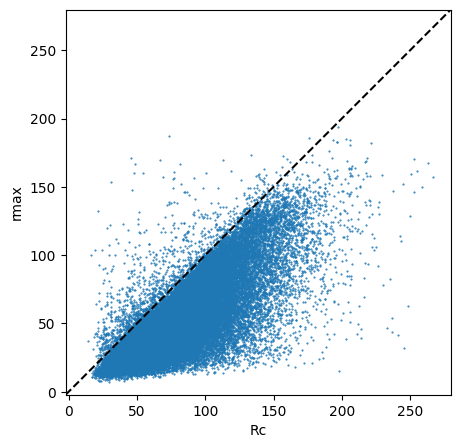

In [73]:
plt.figure(figsize=(5, 5))

plt.scatter(
    df_phys_geom_QC.Rc,
    df_phys_geom_QC.rmax,
    marker='.',
    s=1
)

lims = [
    np.nanmin([plt.xlim()[0], plt.ylim()[0]]),
    np.nanmax([plt.xlim()[1], plt.ylim()[1]])
]

plt.plot(lims, lims, 'k--')

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('Rc')
plt.ylabel('rmax')

plt.gca().set_aspect('equal')

plt.show()

In [16]:
df_phys_geom_QC.columns

Index(['Eddy', 'Day', 'Cyc', 'plon', 'plat', 'pxc', 'pyc', 'pw', 'ke',
       'velmax', 'rmax', 'Age', 'Date', 'fname', 'shapes1', 'area', 'deta',
       'gxc', 'gyc', 'gw', 'Omega', 'Q', 'Rc', 'psi0', 'R', 'AR'],
      dtype='object')

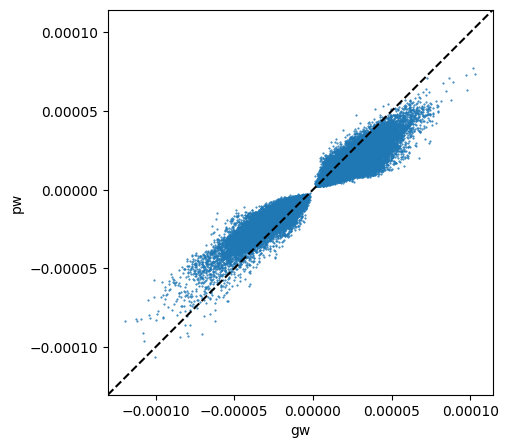

In [71]:
plt.figure(figsize=(5, 5))

plt.scatter(
    df_phys_geom_QC.gw,
    df_phys_geom_QC.pw,
    marker='.',
    s=1
)

lims = [
    np.nanmin([plt.xlim()[0], plt.ylim()[0]]),
    np.nanmax([plt.xlim()[1], plt.ylim()[1]])
]

plt.plot(lims, lims, 'k--')

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('gw')
plt.ylabel('pw')

plt.gca().set_aspect('equal')

plt.show()


In [51]:
data

Eddy                                                    2110
Day                                                     7213
Cyc                                                       AE
plon                                              154.674457
plat                                              -31.636187
pxc                                               403.818707
pyc                                               945.205252
pw                                                  0.000019
ke                                                275.101691
velmax                                              0.755107
rmax                                               88.249314
Age                                                      297
Date                                     2009-10-01 00:00:00
fname      /srv/scratch/z3533156/26year_BRAN2020/outer_av...
shapes1    Path(array([[156.12251519, -32.03513621],\n   ...
area                                            24466.539553
deta                    

In [65]:
def plot_geom_vs_phys_examples(
    df,
    lon_rho,
    lat_rho,
    X_grid,
    Y_grid,
    nrows=3,
    ncols=3,
    figsize=(6, 6),
    seed=None
):

    if seed is not None:
        np.random.seed(seed)

    valid_Q = df['Q'].apply(
        lambda Q: isinstance(Q, np.ndarray)
        and Q.shape == (2, 2)
        and np.isfinite(Q).all()
    )

    valid_Rc = np.isfinite(df['Rc']) & (df['Rc'] > 0)

    valid = valid_Q & valid_Rc

    n = nrows * ncols

    idxs = np.random.choice(df.index[valid], n, replace=False)

    points = np.column_stack([lon_rho.ravel(), lat_rho.ravel()])
    values = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        constrained_layout=True
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, idx in zip(axes, idxs):

        data = df.loc[idx]

        color = 'r' if data.Cyc == 'AE' else 'c'

        ax.scatter(data.gxc, data.gyc, marker='x', c='k', s=15)
        ax.scatter(data.pxc, data.pyc, marker='^', c='k', s=15)

        pad = 2.5 * data.rmax

        xg = np.linspace(data.gxc - pad, data.gxc + pad, 200)
        yg = np.linspace(data.gyc - pad, data.gyc + pad, 200)

        Xg, Yg = np.meshgrid(xg, yg)

        dx = Xg - data.gxc
        dy = Yg - data.gyc

        rho2 = (
            data.Q[0,0] * dx**2
            + 2 * data.Q[1,0] * dx * dy
            + data.Q[1,1] * dy**2
        )

        ax.contour(
            Xg,
            Yg,
            rho2,
            levels=[data.Rc**2 / 2],
            colors=color,
            linestyles='--'
        )

        xy = griddata(
            points,
            values,
            data.shapes1.vertices,
            method='linear'
        )

        ax.plot(xy[:, 0], xy[:, 1], color=color)

        ax.set_aspect('equal')

        ax.set_xlim(data.gxc - pad, data.gxc + pad)
        ax.set_ylim(data.gyc - pad, data.gyc + pad)

        ax.set_title(
            f'E{data.Eddy} D{data.Day}',
            fontsize=8
        )

    return fig, axes
    

(<Figure size 600x600 with 9 Axes>,
 array([<Axes: title={'center': 'E1807 D6325'}>,
        <Axes: title={'center': 'E1001 D4178'}>,
        <Axes: title={'center': 'E2641 D8366'}>,
        <Axes: title={'center': 'E961 D4170'}>,
        <Axes: title={'center': 'E2309 D7585'}>,
        <Axes: title={'center': 'E2099 D6982'}>,
        <Axes: title={'center': 'E740 D3526'}>,
        <Axes: title={'center': 'E838 D3748'}>,
        <Axes: title={'center': 'E3428 D10513'}>], dtype=object))

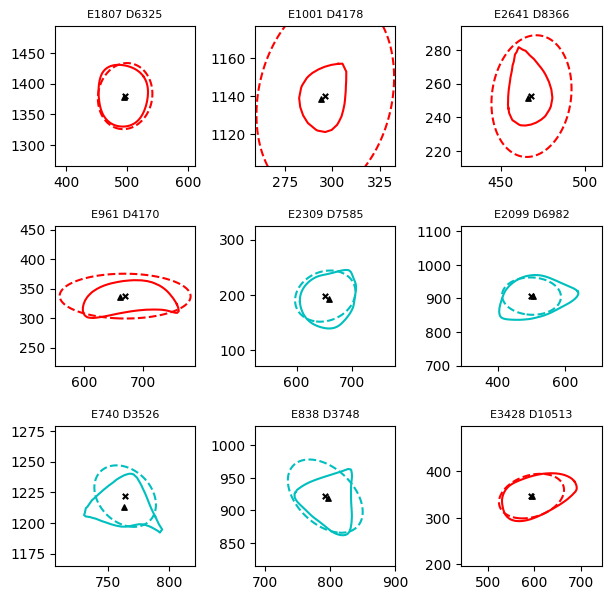

In [66]:
plot_geom_vs_phys_examples(
    df_phys_geom_QC,
    lon_rho,
    lat_rho,
    X_grid,
    Y_grid
)


(<Figure size 600x600 with 9 Axes>,
 array([<Axes: title={'center': 'E1389 D5364'}>,
        <Axes: title={'center': 'E2844 D8978'}>,
        <Axes: title={'center': 'E2088 D7053'}>,
        <Axes: title={'center': 'E2732 D8647'}>,
        <Axes: title={'center': 'E1491 D5535'}>,
        <Axes: title={'center': 'E1947 D6674'}>,
        <Axes: title={'center': 'E3100 D9524'}>,
        <Axes: title={'center': 'E1487 D5482'}>,
        <Axes: title={'center': 'E271 D2135'}>], dtype=object))

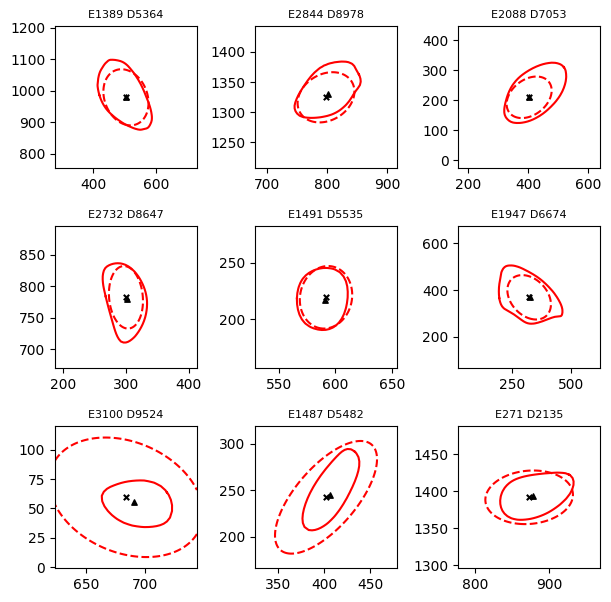

In [67]:
plot_geom_vs_phys_examples(
    df_phys_geom_QC,
    lon_rho,
    lat_rho,
    X_grid,
    Y_grid
)


(<Figure size 600x600 with 9 Axes>,
 array([<Axes: title={'center': 'E2823 D9037'}>,
        <Axes: title={'center': 'E3248 D9956'}>,
        <Axes: title={'center': 'E3062 D9414'}>,
        <Axes: title={'center': 'E1956 D6672'}>,
        <Axes: title={'center': 'E3167 D9693'}>,
        <Axes: title={'center': 'E2040 D6803'}>,
        <Axes: title={'center': 'E2235 D7365'}>,
        <Axes: title={'center': 'E1077 D4399'}>,
        <Axes: title={'center': 'E2051 D6850'}>], dtype=object))

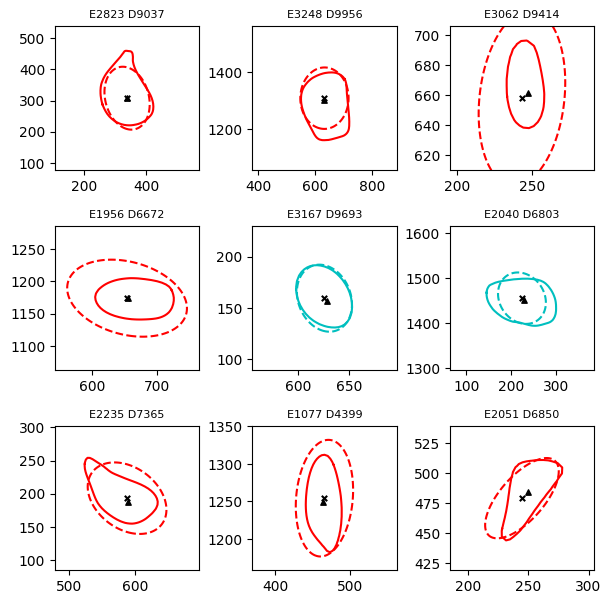

In [68]:
plot_geom_vs_phys_examples(
    df_phys_geom_QC,
    lon_rho,
    lat_rho,
    X_grid,
    Y_grid
)


(<Figure size 600x600 with 9 Axes>,
 array([<Axes: title={'center': 'E2145 D7087'}>,
        <Axes: title={'center': 'E3071 D9478'}>,
        <Axes: title={'center': 'E375 D2467'}>,
        <Axes: title={'center': 'E1082 D4412'}>,
        <Axes: title={'center': 'E301 D2251'}>,
        <Axes: title={'center': 'E2528 D8076'}>,
        <Axes: title={'center': 'E2245 D7387'}>,
        <Axes: title={'center': 'E1764 D6173'}>,
        <Axes: title={'center': 'E2996 D9365'}>], dtype=object))

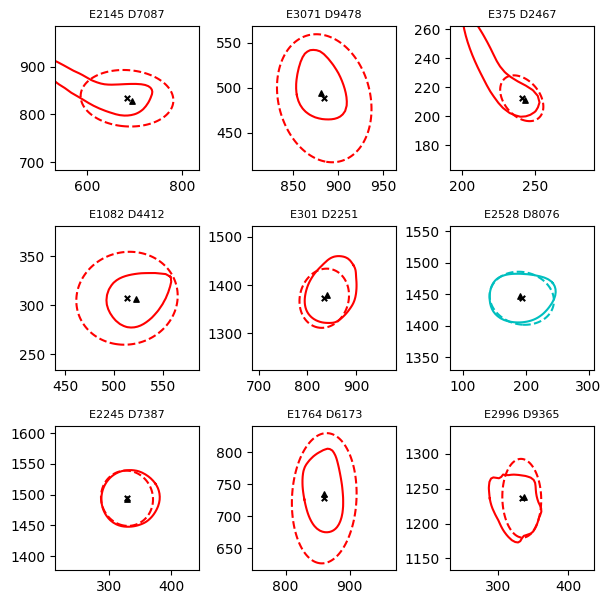

In [69]:
plot_geom_vs_phys_examples(
    df_phys_geom_QC,
    lon_rho,
    lat_rho,
    X_grid,
    Y_grid
)


(array([3.9710e+03, 1.0030e+04, 1.2763e+04, 1.2808e+04, 1.1273e+04,
        9.3450e+03, 7.8100e+03, 6.2760e+03, 4.9630e+03, 3.9510e+03,
        3.2050e+03, 2.6160e+03, 2.0890e+03, 1.7440e+03, 1.4420e+03,
        1.1300e+03, 8.9800e+02, 7.1800e+02, 6.3900e+02, 5.3300e+02,
        4.2600e+02, 3.5200e+02, 2.9200e+02, 2.6200e+02, 2.4300e+02,
        1.9700e+02, 1.7900e+02, 1.5700e+02, 1.5000e+02, 1.1600e+02,
        1.1200e+02, 9.8000e+01, 9.9000e+01, 8.1000e+01, 7.8000e+01,
        7.2000e+01, 5.4000e+01, 5.9000e+01, 6.2000e+01, 4.6000e+01,
        4.5000e+01, 5.0000e+01, 4.1000e+01, 3.8000e+01, 4.2000e+01,
        3.8000e+01, 4.6000e+01, 2.9000e+01, 2.6000e+01, 2.7000e+01,
        2.3000e+01, 2.6000e+01, 2.1000e+01, 1.9000e+01, 2.0000e+01,
        2.5000e+01, 2.0000e+01, 1.3000e+01, 1.8000e+01, 2.2000e+01,
        1.5000e+01, 1.4000e+01, 9.0000e+00, 1.7000e+01, 1.1000e+01,
        1.0000e+01, 9.0000e+00, 1.9000e+01, 1.1000e+01, 1.3000e+01,
        1.2000e+01, 9.0000e+00, 1.2000e+01, 1.20

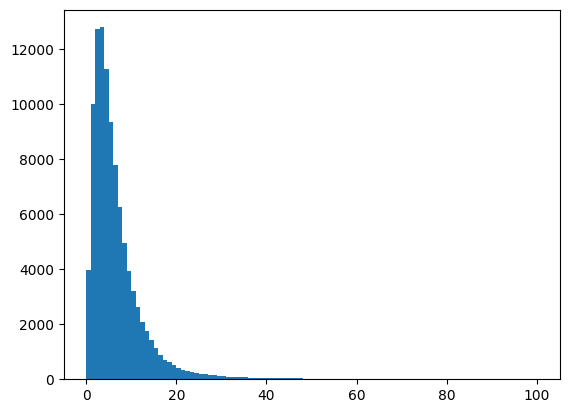

In [70]:
plt.hist(np.hypot(df_phys_geom_QC.pxc - df_phys_geom_QC.gxc, df_phys_geom_QC.pyc - df_phys_geom_QC.gyc), bins=100)
